# Customer Churn Analysis and Predictive Modeling Using Machine Learning

### Project Overview

This project analyzes customer churn behavior using the IBM Telco Customer Churn dataset and develops machine learning models to predict whether a customer is likely to churn.

The project covers:

- Data loading and understanding
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Customer churn pattern analysis
- Machine learning model development
- Model evaluation and comparison
- Feature importance analysis
- Churn prediction for new customers

**Tools & Technologies:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

## 1. Import Libraries

The following Python libraries are used for data manipulation, visualization, and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

## 2. Load the Dataset

The dataset used in this project is the IBM Telco Customer Churn dataset. It contains customer information, subscribed services, account details, and churn status.

In [2]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


The dataset was successfully loaded into a Pandas DataFrame. The `df.head()` output is used to verify that the data has been loaded correctly.

## 3. Dataset Overview

Before performing any analysis, the dataset is examined to understand its size, structure, data types, and basic statistical properties.

In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (7043, 21)

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### Statistical Summary

The following summary provides descriptive statistics for the numerical variables in the dataset.

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 4. Data Cleaning

Data cleaning is performed to identify missing values, duplicate records, and incorrect data types before carrying out further analysis.

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

### Cleaning the `TotalCharges` Column

The `TotalCharges` column contains 11 blank values. These blank values are converted to missing values, the column is converted to numeric format, and the remaining missing values are replaced with `0`.

In [8]:
df["TotalCharges"] = df["TotalCharges"].str.strip().replace("", pd.NA)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])
df["TotalCharges"] = df["TotalCharges"].fillna(0)

### Checking for Duplicate Records

Duplicate records are checked to ensure that the same customer is not unintentionally represented multiple times.

In [9]:
print("Duplicate rows:",df.duplicated().sum())

Duplicate rows: 0


In [10]:
df["customerID"].duplicated().sum()

np.int64(0)

## 5. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to identify patterns and relationships between customer characteristics and churn behavior.

### 5.1 Overall Churn Distribution

The distribution of churned and non-churned customers is examined to understand the balance of the target variable.

In [11]:
churn_counts = df["Churn"].value_counts(normalize=True)*100
churn_counts

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

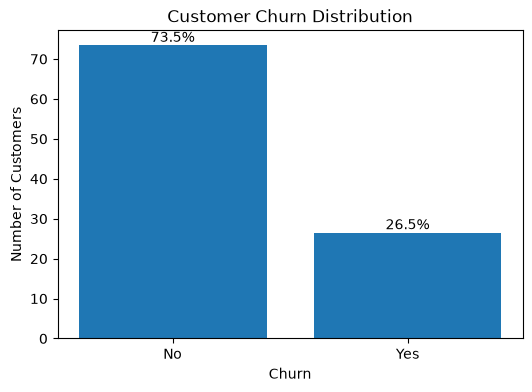

In [12]:
plt.figure(figsize=(6, 4))

bars = plt.bar(churn_counts.index, churn_counts.values)

plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Distribution")

for bar, percentage in zip(bars, churn_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.1f}%",
        ha="center",
        va="bottom"
    )

plt.show()

### Observation

Approximately 26.5% of customers in the dataset have churned, while approximately 73.5% have remained with the company. This indicates that churn is not evenly distributed across the dataset and should be considered when evaluating machine learning models.

### 5.2 Contract Type vs Churn

The relationship between contract type and customer churn is analyzed to determine whether customers with different contract durations show different churn behavior.

In [13]:
Churn_contract = df.groupby("Contract")["Churn"].value_counts(normalize=True).unstack()*100
Churn_contract

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


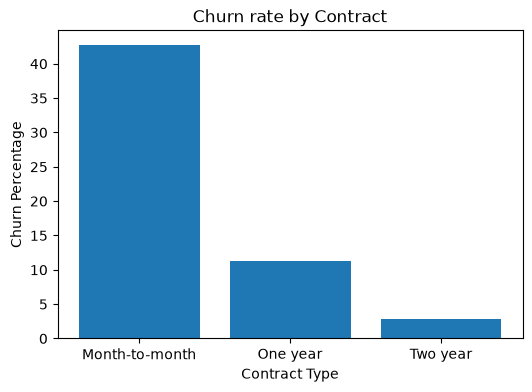

In [14]:
plt.figure(figsize=(6, 4))

plt.bar(Churn_contract.index, Churn_contract["Yes"])

plt.xlabel("Contract Type")
plt.ylabel("Churn Percentage")
plt.title("Churn rate by Contract")

plt.show()

### Observation

Customers with month-to-month contracts have a substantially higher churn rate than customers with one-year and two-year contracts. The churn rate decreases as the contract duration increases.

### 5.3 Internet Service vs Churn

The relationship between internet service type and customer churn is analyzed to identify whether churn rates differ across internet service categories.

In [15]:
internet_churn = df.groupby("InternetService")["Churn"].value_counts(normalize=True).unstack()*100
internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


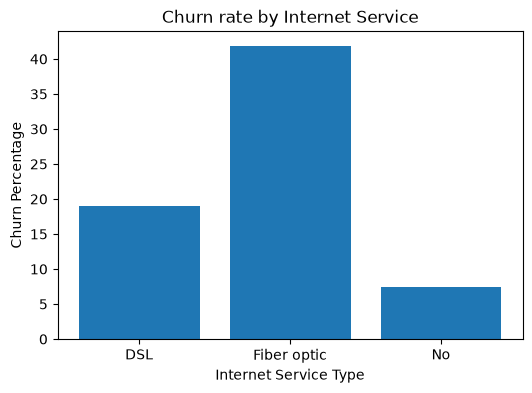

In [16]:
plt.figure(figsize=(6, 4))

plt.bar(internet_churn.index, internet_churn["Yes"])

plt.xlabel("Internet Service Type")
plt.ylabel("Churn Percentage")
plt.title("Churn rate by Internet Service")

plt.show()

### Observation

Fiber optic customers have the highest churn rate among the three internet service categories, while customers without internet service have the lowest churn rate.

### 5.4 Customer Tenure vs Churn

Customer tenure represents the number of months a customer has been with the company. The average tenure of churned and non-churned customers is compared to identify differences in customer retention.

In [17]:
tenure_churn = df.groupby("Churn")["tenure"].mean()
tenure_churn

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

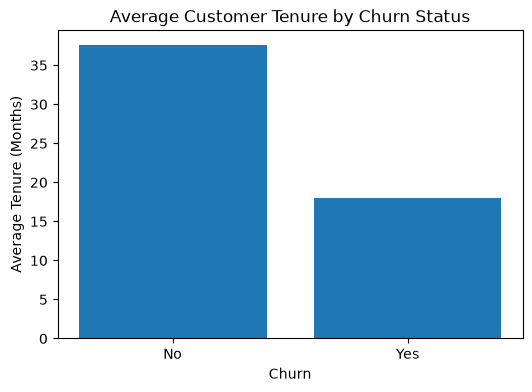

In [18]:
plt.figure(figsize=(6, 4))

plt.bar(tenure_churn.index, tenure_churn.values)

plt.xlabel("Churn")
plt.ylabel("Average Tenure (Months)")
plt.title("Average Customer Tenure by Churn Status")

plt.show()

### Observation

Customers who churned had a substantially lower average tenure than customers who remained with the company. This indicates that churn is more common among relatively newer customers in this dataset.

### 5.5 Monthly Charges vs Churn

The average monthly charges of churned and non-churned customers are compared to identify whether pricing levels are associated with customer churn.

In [19]:
monthly_charges = df.groupby("Churn")["MonthlyCharges"].mean()
monthly_charges

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

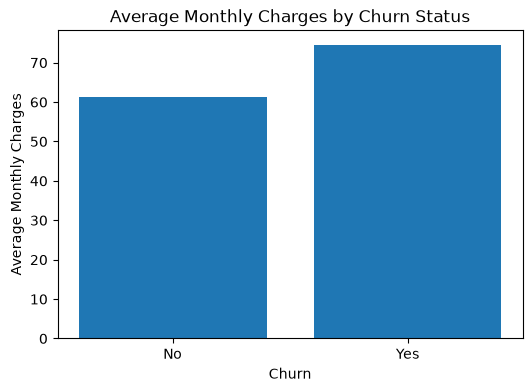

In [20]:
plt.figure(figsize=(6, 4))

plt.bar(monthly_charges.index, monthly_charges.values)

plt.xlabel("Churn")
plt.ylabel("Average Monthly Charges")
plt.title("Average Monthly Charges by Churn Status")

plt.show()

### Observation

Customers who churned had higher average monthly charges than customers who remained with the company. This suggests that higher monthly charges are associated with higher churn in this dataset.

### 5.6 Payment Method vs Churn

The relationship between payment method and customer churn is analyzed to identify differences in churn rates across payment methods.

In [21]:
payment_method = df.groupby("PaymentMethod")["Churn"].value_counts(normalize=True).unstack()*100
payment_method

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


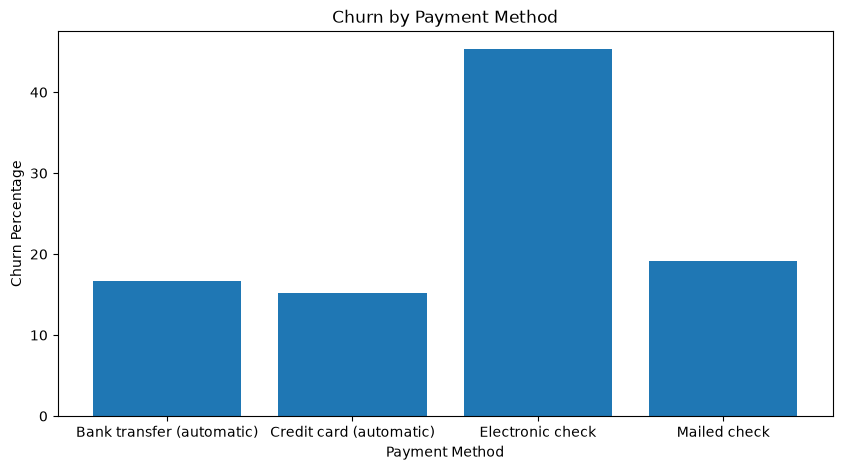

In [22]:
plt.figure(figsize=(10, 5))

plt.bar(payment_method.index, payment_method["Yes"])

plt.xlabel("Payment Method")
plt.ylabel("Churn Percentage")
plt.title("Churn by Payment Method")

plt.show()

### Observation

Churn rates vary across payment methods. Electronic check customers show a notably higher churn rate compared with customers using automatic payment methods.

### 5.7 Tech Support vs Churn

The relationship between technical support services and customer churn is analyzed to determine whether churn rates differ between customers with and without tech support.

In [23]:
tech_support = df.groupby("TechSupport")["Churn"].value_counts(normalize=True).unstack()*100
tech_support

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


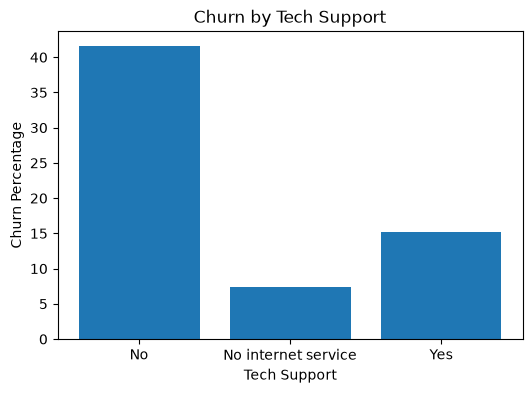

In [24]:
plt.figure(figsize=(6, 4))

plt.bar(tech_support.index, tech_support["Yes"])

plt.xlabel("Tech Support")
plt.ylabel("Churn Percentage")
plt.title("Churn by Tech Support")

plt.show()

### Observation

Customers without technical support show a higher churn rate than customers with technical support in this dataset. Customers with no internet service form a separate category because they do not use internet-based services.

### 5.8 Senior Citizen Status vs Churn

The relationship between senior citizen status and customer churn is analyzed to determine whether churn rates differ between senior and non-senior customers.

In [25]:
senior_citizen = df.groupby("SeniorCitizen")["Churn"].value_counts(normalize=True).unstack()*100
senior_citizen

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


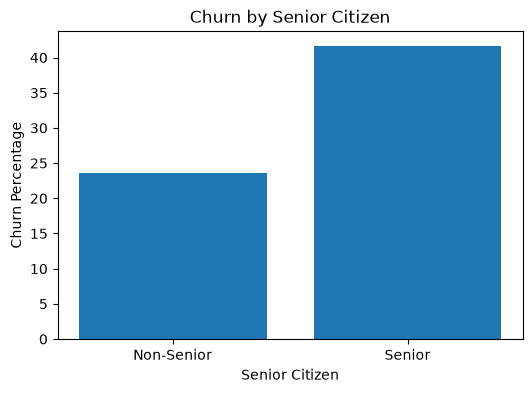

In [26]:
plt.figure(figsize=(6, 4))

senior_citizen.index = ["Non-Senior", "Senior"]
plt.bar(senior_citizen.index, senior_citizen["Yes"])

plt.xlabel("Senior Citizen")
plt.ylabel("Churn Percentage")
plt.title("Churn by Senior Citizen")

plt.show()

### Observation

The churn rate differs between senior and non-senior customers in this dataset. Senior citizen status may therefore provide useful information for predicting customer churn.

## 6. Key Findings from Exploratory Data Analysis

The exploratory analysis revealed several patterns associated with customer churn:

- **Contract Type:** Month-to-month customers have a considerably higher churn rate than customers with one-year and two-year contracts.
- **Internet Service:** Fiber optic customers have the highest churn rate among the internet service categories.
- **Tenure:** Churned customers have a lower average tenure than customers who remain with the company.
- **Monthly Charges:** Churned customers have higher average monthly charges than non-churned customers.
- **Payment Method:** Customers using electronic checks show a higher churn rate compared with several other payment methods.
- **Tech Support:** Customers without technical support show a higher churn rate than customers with technical support.
- **Senior Citizen Status:** Churn rates differ between senior and non-senior customers.

These findings provide useful insights for selecting variables and developing the machine learning models in the next stage.

## 7. Data Preprocessing for Machine Learning

Machine learning algorithms require numerical input. The categorical variables in the dataset are therefore converted into numerical representations before training the models.

### 7.1 Remove Customer ID

The `customerID` column is removed because it uniquely identifies each customer and does not provide useful predictive information for churn modeling.

In [27]:
df = df.drop("customerID", axis=1)

### 7.2 Separate Features and Target

The target variable is `Churn`, which indicates whether a customer left the company. All remaining columns are used as input features for the machine learning models.

In [28]:
X = df.drop("Churn", axis=1)
Y = df["Churn"]

### 7.3 Encode the Target Variable

The `Churn` target contains two categories: `No` and `Yes`. These are converted into numerical values, where `0` represents customers who did not churn and `1` represents customers who churned.

In [29]:
Y = Y.replace({"Yes":1, "No":0})
Y = Y.astype(int)
Y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [30]:
print(Y.dtype)
print(Y.unique())

int64
[0 1]


### 7.4 Identify Categorical Features

Categorical columns are identified so that they can be converted into numerical form before training the machine learning models.

In [31]:
X_categorical_column = X.select_dtypes(include="object").columns
X_categorical_column

C:\Users\Lakshit Dua\AppData\Local\Temp\ipykernel_27396\2132699096.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X_categorical_column = X.select_dtypes(include="object").columns


Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

### 7.5 One-Hot Encoding

One-hot encoding is used to convert categorical variables into numerical columns that can be processed by machine learning algorithms.

In [32]:
X = pd.get_dummies(X, drop_first=True)
X.shape

(7043, 30)

### 7.6 Train-Test Split

The dataset is divided into training and testing sets. The training data is used to build the machine learning models, while the testing data is used to evaluate their performance on unseen data.

An 80:20 split is used, with 80% of the data for training and 20% for testing.

In [33]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [34]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Y_train:", Y_train.shape)
print("Y_test:", Y_test.shape)

X_train: (5634, 30)
X_test: (1409, 30)
Y_train: (5634,)
Y_test: (1409,)


## 8. Machine Learning Model Development

In this section, machine learning models are trained to predict whether a customer is likely to churn.

The models will be trained using the preprocessed training data and evaluated using the test data.

### 8.1 Logistic Regression

Logistic Regression is used as the first classification model because the target variable has two possible outcomes: churn (`1`) or no churn (`0`).

In [35]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, Y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

### 8.2 Make Predictions

After training the Logistic Regression model, predictions are made on the test dataset. The model predicts whether each customer is likely to churn (`1`) or stay (`0`).

In [36]:
Y_prediction = model.predict(X_test)
Y_prediction[:20]

array([1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0])

### 8.3 Actual vs Predicted Values

The predicted churn values are compared with the actual churn values from the test dataset to evaluate how well the model performs on unseen customers.

In [37]:
comparison = pd.DataFrame({
    "Actual": Y_test.values,
    "Predicted": Y_prediction
})

comparison.head(10)

,Actual,Predicted
0,1,1
1,0,0
2,0,0
3,1,1
4,0,0
5,1,0
6,0,0
7,0,0
8,1,0
9,1,0


### 8.4 Model Accuracy

Accuracy measures the percentage of test customers for whom the model made the correct prediction.

In [38]:
accuracy = accuracy_score(Y_test, Y_prediction)
print("Logistic Regression Accuracy:", accuracy * 100, "%")

Logistic Regression Accuracy: 82.18594748048261 %


### 8.5 Confusion Matrix

A confusion matrix shows the number of correct and incorrect predictions made by the model for each class.

- **True Negative (TN):** Correctly predicted a customer will stay.
- **False Positive (FP):** Predicted churn, but the customer actually stayed.
- **False Negative (FN):** Predicted stay, but the customer actually churned.
- **True Positive (TP):** Correctly predicted a customer will churn.

In [39]:
cm = confusion_matrix(Y_test, Y_prediction)
cm

array([[934, 102],
       [149, 224]])

### 8.6 Confusion Matrix Visualization

The confusion matrix is visualized as a heatmap to make the model's correct and incorrect predictions easier to interpret.

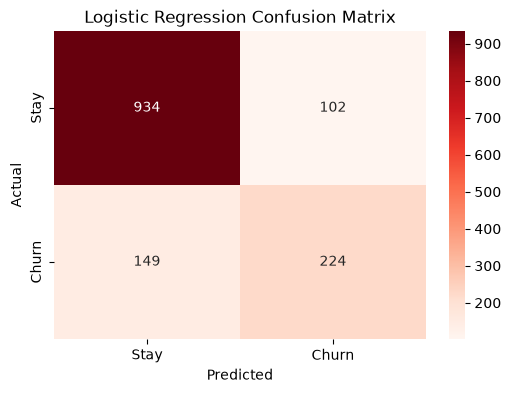

In [40]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=["Stay", "Churn"],
    yticklabels=["Stay", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

### 8.7 Classification Report

The classification report provides precision, recall, and F1-score for both churn classes. These metrics help evaluate how effectively the model identifies customers who churn and customers who stay.
- **Precision:** Of the customers predicted to churn, how many actually churned.
- **Recall:** Of the customers who actually churned, how many were correctly identified by the model.
- **F1-score:** A combined measure of precision and recall.

In [41]:
report = classification_report(Y_test, Y_prediction)
print(report)

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



### 8.8 ROC-AUC Score

ROC-AUC measures the model's ability to distinguish between customers who churn and customers who do not churn.

A higher ROC-AUC generally indicates better separation between the two classes.

In [42]:
Y_probab = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(Y_test, Y_probab)

print("Logistic Regression ROC-AUC:", auc)

Logistic Regression ROC-AUC: 0.8625138447524505


## 9. Decision Tree

A Decision Tree is a classification model that makes predictions by splitting the data based on different features. It creates a tree-like structure of decisions to classify customers as likely to churn or stay.

## 9. Decision Tree

A Decision Tree is a classification model that makes predictions by splitting the data based on different features. It creates a tree-like structure of decisions to classify customers as likely to churn or stay.

In [43]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, Y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples

### 9.2 Make Predictions

The trained Decision Tree model is used to predict whether customers in the test dataset will churn or stay.

In [44]:
dt_pred = dt_model.predict(X_test)
dt_pred[:10]

array([1, 1, 0, 0, 0, 0, 0, 0, 1, 1])

### 9.3 Actual vs Predicted Values

The predicted churn values from the Decision Tree are compared with the actual churn values from the test dataset to evaluate the model's predictions.

In [45]:
dt_comparison = pd.DataFrame({
    "Actual": Y_test.values,
    "Predicted": dt_pred
})

dt_comparison.head(10)

,Actual,Predicted
0,1,1
1,0,1
2,0,0
3,1,0
4,0,0
5,1,0
6,0,0
7,0,0
8,1,1
9,1,1


### 9.4 Decision Tree Accuracy

Accuracy measures the percentage of test customers that were correctly classified by the Decision Tree model.

In [46]:
dt_accuracy = accuracy_score(Y_test, dt_pred)
print("Decision Tree Accuracy:", dt_accuracy * 100, "%")

Decision Tree Accuracy: 71.46912704045423 %


### 9.5 Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions made by the Decision Tree for customers who stayed and customers who churned.

In [47]:
dt_cm = confusion_matrix(Y_test, dt_pred)
print(dt_cm)

[[835 201]
 [201 172]]


### 9.6 Confusion Matrix Visualization

The Decision Tree confusion matrix is visualized as a heatmap to make the model's correct and incorrect predictions easier to interpret.

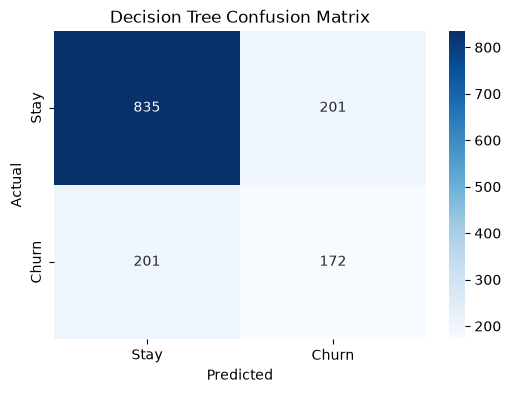

In [48]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stay", "Churn"],
    yticklabels=["Stay", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

### 9.7 Classification Report

The classification report provides precision, recall, and F1-score for the Decision Tree model. These metrics provide a more detailed evaluation of the model's performance for both churn and non-churn customers.

In [49]:
dt_report = classification_report(Y_test, dt_pred)
print(dt_report)

              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1036
           1       0.46      0.46      0.46       373

    accuracy                           0.71      1409
   macro avg       0.63      0.63      0.63      1409
weighted avg       0.71      0.71      0.71      1409



### 9.8 ROC-AUC Score

ROC-AUC measures the Decision Tree model's ability to distinguish between customers who churn and customers who do not churn.

In [50]:
dt_prob = dt_model.predict_proba(X_test)[:, 1]
dt_auc = roc_auc_score(Y_test, dt_prob)
print("Decision Tree ROC-AUC:", dt_auc)

Decision Tree ROC-AUC: 0.6341168341838583


## 10. Random Forest

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to make predictions. It can capture complex relationships in the data and is generally more robust than using a single Decision Tree.

### 10.1 Train the Random Forest Model

The Random Forest model is trained using the same training dataset used for the previous models so that its performance can be compared fairly.

In [51]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, Y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

### 10.2 Make Predictions

The trained Random Forest model is used to predict whether customers in the test dataset will churn or stay.

In [52]:
rf_pred = rf_model.predict(X_test)
rf_pred[:10]

array([1, 0, 0, 1, 0, 0, 0, 0, 0, 0])

### 10.3 Actual vs Predicted Values

The predicted churn values from the Random Forest model are compared with the actual churn values from the test dataset to evaluate the model's predictions.

In [53]:
rf_comparison = pd.DataFrame({
    "Actual": Y_test.values,
    "Predicted": rf_pred
})

rf_comparison.head(10)

,Actual,Predicted
0,1,1
1,0,0
2,0,0
3,1,1
4,0,0
5,1,0
6,0,0
7,0,0
8,1,0
9,1,0


### 10.4 Random Forest Accuracy

Accuracy measures the percentage of test customers that were correctly classified by the Random Forest model.

In [54]:
rf_accuracy = accuracy_score(Y_test, rf_pred)
print("Random Forest Accuracy:", rf_accuracy * 100, "%")

Random Forest Accuracy: 78.49538679914833 %


### 10.5 Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions made by the Random Forest model for customers who stayed and customers who churned.

In [55]:
rf_cm = confusion_matrix(Y_test, rf_pred)
print(rf_cm)

[[943  93]
 [210 163]]


### 10.6 Confusion Matrix Visualization

The Random Forest confusion matrix is visualized as a heatmap to make the model's correct and incorrect predictions easier to interpret.

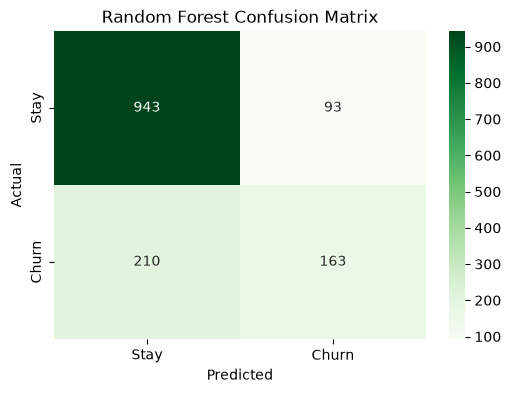

In [56]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Stay", "Churn"],
    yticklabels=["Stay", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

### 10.7 Classification Report

The classification report provides precision, recall, and F1-score for the Random Forest model. These metrics provide a more detailed evaluation of the model's performance for both churn and non-churn customers.


In [57]:
rf_report = classification_report(Y_test, rf_pred)
print(rf_report)

              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.64      0.44      0.52       373

    accuracy                           0.78      1409
   macro avg       0.73      0.67      0.69      1409
weighted avg       0.77      0.78      0.77      1409



### 10.8 ROC-AUC Score

ROC-AUC measures the Random Forest model's ability to distinguish between customers who churn and customers who do not churn.

A higher ROC-AUC generally indicates better ability to separate the two classes.

In [58]:
rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(Y_test, rf_prob)
print("Random Forest ROC-AUC:", rf_auc)

Random Forest ROC-AUC: 0.8368337698096411


## 11. K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a supervised machine learning algorithm that classifies a customer based on the classes of the nearest data points.

For this project, KNN is used to predict whether a customer is likely to churn or stay.

### 11.1 Train the KNN Model

The KNN classifier is trained using the same training dataset used for the other machine learning models.

In [59]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, Y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


### 11.2 Make Predictions

The trained KNN model is used to predict whether customers in the test dataset will churn or stay.

In [60]:
knn_pred = knn_model.predict(X_test)
knn_pred[:10]

array([1, 0, 0, 1, 0, 0, 1, 0, 0, 0])

### 11.3 Actual vs Predicted Values

The predicted churn values from the KNN model are compared with the actual churn values from the test dataset to evaluate the model's predictions.

In [61]:
knn_comparison = pd.DataFrame({
    "Actual": Y_test.values,
    "Predicted": knn_pred
})

knn_comparison.head(10)

,Actual,Predicted
0,1,1
1,0,0
2,0,0
3,1,1
4,0,0
5,1,0
6,0,1
7,0,0
8,1,0
9,1,0


### 11.4 KNN Accuracy

Accuracy measures the percentage of test customers that were correctly classified by the KNN model.

In [62]:
knn_accuracy = accuracy_score(Y_test, knn_pred)
print("KNN Accuracy:", knn_accuracy * 100, "%")

KNN Accuracy: 77.71469127040454 %


### 11.5 Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions made by the KNN model for customers who stayed and customers who churned.

In [63]:
knn_cm = confusion_matrix(Y_test, knn_pred)
print(knn_cm)

[[914 122]
 [192 181]]


### 11.6 Confusion Matrix Visualization

The KNN confusion matrix is visualized as a heatmap to make the model's correct and incorrect predictions easier to interpret.

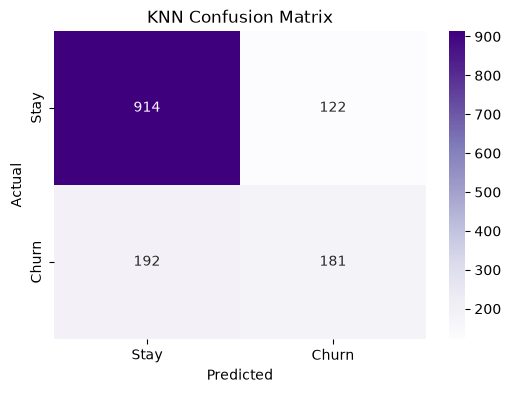

In [64]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    knn_cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Stay", "Churn"],
    yticklabels=["Stay", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

### 11.7 Classification Report

The classification report provides precision, recall, and F1-score for the KNN model. These metrics provide a more detailed evaluation of the model's performance for both churn and non-churn customers.

In [65]:
knn_report = classification_report(Y_test, knn_pred)
print(knn_report)

              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1036
           1       0.60      0.49      0.54       373

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



### 11.8 ROC-AUC Score

ROC-AUC measures the KNN model's ability to distinguish between customers who churn and customers who do not churn.

A higher ROC-AUC generally indicates better ability to separate the two classes.

In [66]:
knn_prob = knn_model.predict_proba(X_test)[:, 1]
knn_auc = roc_auc_score(Y_test, knn_prob)
print("KNN ROC-AUC:", knn_auc)

KNN ROC-AUC: 0.7745841398656412


## 12. Support Vector Machine (SVM)

Support Vector Machine (SVM) is a supervised machine learning algorithm that finds a decision boundary that separates different classes.

In this project, SVM is used to classify customers into two categories: likely to churn and likely to stay.

### 12.1 Train the SVM Model

The SVM classifier is trained using the same training dataset used for the other machine learning models.

In [67]:
svm_model = SVC(probability=True,random_state=42)
svm_model.fit(X_train, Y_train)

c:\Users\Lakshit Dua\anaconda3\envs\bookenv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


### 12.2 Make Predictions

The trained SVM model is used to predict whether customers in the test dataset will churn or stay.

In [68]:
svm_pred = svm_model.predict(X_test)
svm_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

### 12.3 Actual vs Predicted Values

The predicted churn values from the SVM model are compared with the actual churn values from the test dataset.

In [69]:
svm_comparison = pd.DataFrame({
    "Actual": Y_test.values,
    "Predicted": svm_pred
})
svm_comparison.head(10)

,Actual,Predicted
0,1,0
1,0,0
2,0,0
3,1,0
4,0,0
5,1,0
6,0,0
7,0,0
8,1,0
9,1,0


### 12.4 SVM Accuracy

Accuracy measures the percentage of test customers that were correctly classified by the SVM model.

In [70]:
svm_accuracy = accuracy_score(Y_test, svm_pred)
print("SVM Accuracy:", svm_accuracy * 100, "%")

SVM Accuracy: 73.52732434350602 %


### 12.5 Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions made by the SVM model.

In [71]:
svm_cm = confusion_matrix(Y_test, svm_pred)
print(svm_cm)

[[1036    0]
 [ 373    0]]


### 11.6 Confusion Matrix Visualization

The SVM confusion matrix is visualized as a heatmap to make the model's correct and incorrect predictions easier to interpret.

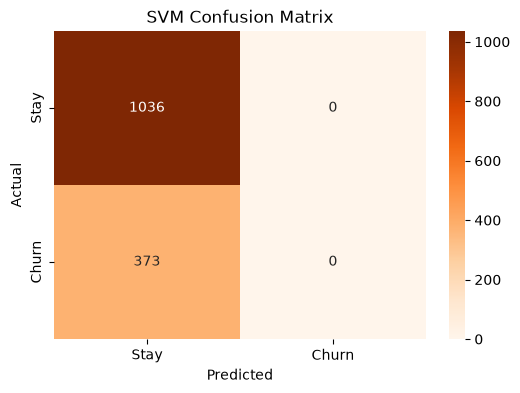

In [72]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Stay", "Churn"],
    yticklabels=["Stay", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

### 12.7 Classification Report

The classification report provides precision, recall, and F1-score for the SVM model.

In [73]:
svm_report = classification_report(Y_test, svm_pred)
print(svm_report)

              precision    recall  f1-score   support

           0       0.74      1.00      0.85      1036
           1       0.00      0.00      0.00       373

    accuracy                           0.74      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.74      0.62      1409



c:\Users\Lakshit Dua\anaconda3\envs\bookenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lakshit Dua\anaconda3\envs\bookenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lakshit Dua\anaconda3\envs\bookenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

### 12.8 ROC-AUC Score

ROC-AUC measures the SVM model's ability to distinguish between customers who churn and customers who do not churn.

In [74]:
svm_prob = svm_model.predict_proba(X_test)[:, 1]
svm_auc = roc_auc_score(Y_test, svm_prob)
print("SVM ROC-AUC:", svm_auc)

SVM ROC-AUC: 0.8165958470918258


## 13. Model Comparison

The performance of all five machine learning models is compared using Accuracy and ROC-AUC.

Comparing multiple models helps identify differences in their predictive performance and provides a broader evaluation of the classification approaches used in this project.

In [75]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVM"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy,
        knn_accuracy,
        svm_accuracy
    ],
    "ROC-AUC": [
        auc,
        dt_auc,
        rf_auc,
        knn_auc,
        svm_auc
    ]
})

model_comparison

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.821859,0.862514
1,Decision Tree,0.714691,0.634117
2,Random Forest,0.784954,0.836834
3,KNN,0.777147,0.774584
4,SVM,0.735273,0.816596


### 13.1 Model Accuracy Comparison

The accuracy of all five machine learning models is compared using a bar chart. This provides a visual representation of how accurately each model classified the test customers.

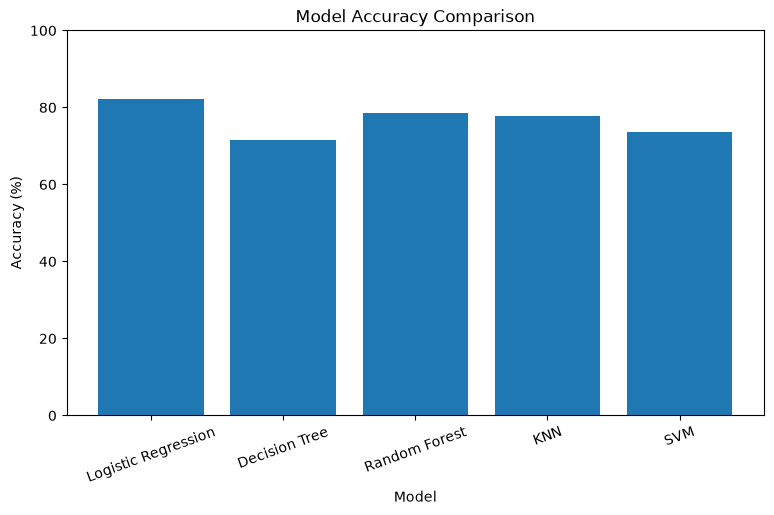

In [76]:
plt.figure(figsize=(9, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["Accuracy"] * 100
)

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)
plt.ylim(0, 100)

plt.show()

### 13.2 ROC-AUC Comparison

The ROC-AUC scores of all five models are compared to evaluate their ability to distinguish between customers who churn and customers who stay.

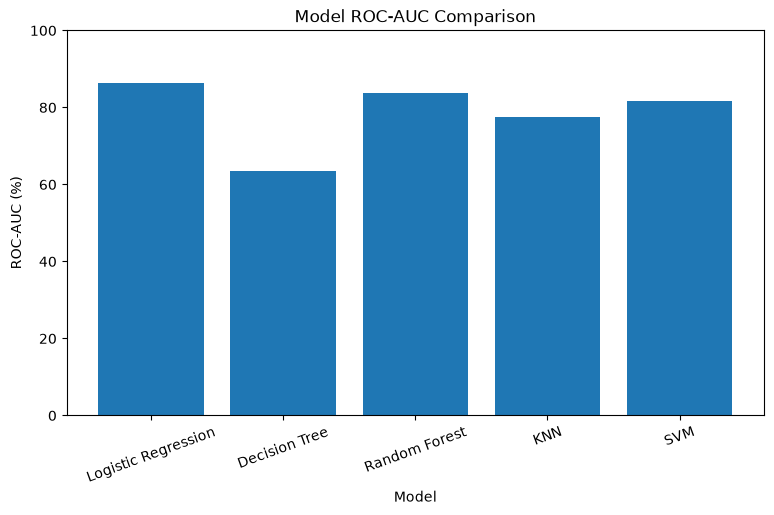

In [77]:
plt.figure(figsize=(9, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["ROC-AUC"] * 100
)

plt.xlabel("Model")
plt.ylabel("ROC-AUC (%)")
plt.title("Model ROC-AUC Comparison")
plt.xticks(rotation=20)
plt.ylim(0, 100)

plt.show()

## 14. Feature Importance

Feature importance helps identify which variables contribute most to the predictions made by a machine learning model.

In this project, feature importance from the Random Forest model is analyzed to understand which customer characteristics are most useful for predicting customer churn.

The importance values indicate the relative contribution of each feature to the model's decision-making process. Higher values indicate that the feature was more useful to the Random Forest model when making predictions.

### 14.1 Calculate Feature Importance

The Random Forest model provides a feature importance score for each input variable. These scores are extracted and organized into a DataFrame for further analysis.

In [78]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,TotalCharges,0.192677
2,MonthlyCharges,0.172247
1,tenure,0.171681
10,InternetService_Fiber optic,0.037451
28,PaymentMethod_Electronic check,0.035764
25,Contract_Two year,0.029908
13,OnlineSecurity_Yes,0.029213
4,gender_Male,0.026934
26,PaperlessBilling_Yes,0.025771
19,TechSupport_Yes,0.023863


### 14.2 Top 10 Important Features

The top 10 features with the highest importance scores are selected for visualization. This helps identify the customer characteristics that contribute most to the Random Forest model's predictions.

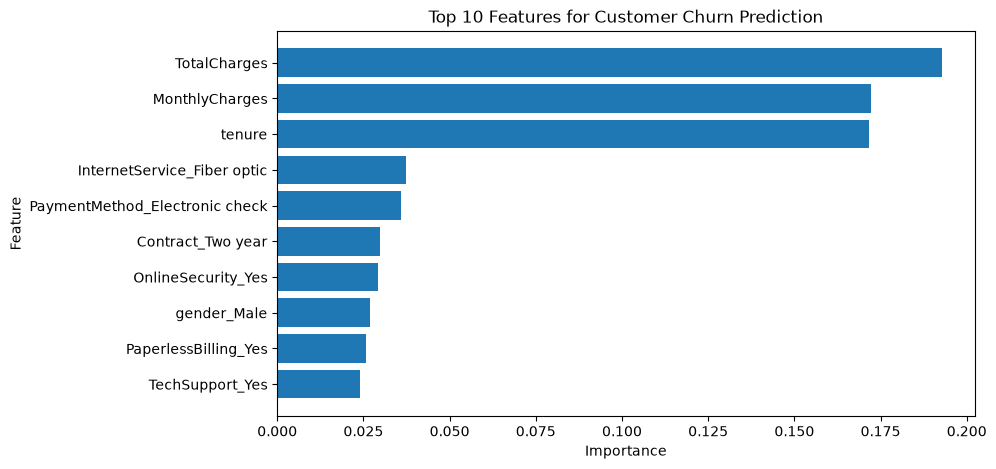

In [79]:
top_features = feature_importance.head(10)

plt.figure(figsize=(9, 5))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features for Customer Churn Prediction")

plt.show()

### 14.4 Logistic Regression Coefficients

Logistic Regression provides coefficient values that help explain how different features are associated with customer churn.

A positive coefficient indicates that an increase or presence of the feature is associated with a higher likelihood of churn, while a negative coefficient indicates an association with a lower likelihood of churn.

The magnitude of the coefficient represents the strength of the feature's contribution to the model, considering the scale of the input features.

Coefficient analysis provides additional interpretability and helps understand which customer characteristics are associated with churn.

In [80]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients.head(10)

,Feature,Coefficient
10,InternetService_Fiber optic,0.636985
26,PaperlessBilling_Yes,0.336836
28,PaymentMethod_Electronic check,0.325368
8,MultipleLines_No phone service,0.275508
23,StreamingMovies_Yes,0.223399
9,MultipleLines_Yes,0.218201
0,SeniorCitizen,0.162875
21,StreamingTV_Yes,0.123703
5,Partner_Yes,0.055539
2,MonthlyCharges,0.003121


### 14.4 Interpretation

The feature importance analysis provides insights into which customer characteristics are most useful for predicting churn.

Features with higher importance values had a greater influence on the Random Forest model's predictions. These features can be further examined along with the EDA findings to understand customer churn patterns.

It is important to note that feature importance indicates the contribution of a feature to the model's predictions and does not necessarily imply a direct causal relationship with customer churn.

## 15. New Customer Churn Prediction

The trained machine learning model can be used to predict the churn probability of a new customer.

A prediction function is created to accept customer information, apply the same preprocessing used during model training, and generate a churn prediction and probability.

In this section, the Random Forest model is used for the prediction system.

### 15.1 Create a Prediction Function

The following function accepts the required customer attributes and prepares them in the same format as the training data.

The function then uses the trained Random Forest model to predict whether the customer is likely to churn and calculates the probability of churn.

In [81]:
def predict_new_customer(
    gender,
    senior_citizen,
    partner,
    dependents,
    tenure,
    phone_service,
    multiple_lines,
    internet_service,
    online_security,
    online_backup,
    device_protection,
    tech_support,
    streaming_tv,
    streaming_movies,
    contract,
    paperless_billing,
    payment_method,
    monthly_charges,
    total_charges
):
    
    new_customer = pd.DataFrame([{
        "gender": gender,
        "SeniorCitizen": senior_citizen,
        "Partner": partner,
        "Dependents": dependents,
        "tenure": tenure,
        "PhoneService": phone_service,
        "MultipleLines": multiple_lines,
        "InternetService": internet_service,
        "OnlineSecurity": online_security,
        "OnlineBackup": online_backup,
        "DeviceProtection": device_protection,
        "TechSupport": tech_support,
        "StreamingTV": streaming_tv,
        "StreamingMovies": streaming_movies,
        "Contract": contract,
        "PaperlessBilling": paperless_billing,
        "PaymentMethod": payment_method,
        "MonthlyCharges": monthly_charges,
        "TotalCharges": total_charges
    }])

    new_customer = pd.get_dummies(
        new_customer,
        drop_first=True
    )

    new_customer = new_customer.reindex(
        columns=X.columns,
        fill_value=0
    )

    prediction = rf_model.predict(new_customer)[0]

    churn_probability = (
        rf_model.predict_proba(new_customer)[0][1] * 100
    )

    if prediction == 1:
        print("Prediction: Customer is likely to CHURN")
    else:
        print("Prediction: Customer is likely to STAY")

    print(f"Churn Probability: {churn_probability:.2f}%")

    return prediction, churn_probability

### 15.2 Test the Prediction Function

The prediction function is tested using sample customer information to demonstrate how the trained Random Forest model can be used for a new customer.

In [82]:
prediction, probability = predict_new_customer(
    gender="Male",
    senior_citizen=0,
    partner="Yes",
    dependents="No",
    tenure=12,
    phone_service="Yes",
    multiple_lines="No",
    internet_service="Fiber optic",
    online_security="No",
    online_backup="No",
    device_protection="No",
    tech_support="No",
    streaming_tv="Yes",
    streaming_movies="Yes",
    contract="Month-to-month",
    paperless_billing="Yes",
    payment_method="Electronic check",
    monthly_charges=85.50,
    total_charges=1026.00
)

Prediction: Customer is likely to STAY
Churn Probability: 30.00%


### 15.3 Prediction Output

The prediction system returns two outputs:

- **Prediction:** Indicates whether the customer is predicted to stay or churn.
- **Churn Probability:** Represents the probability of the customer belonging to the churn class.

This demonstrates how the trained machine learning model can be applied to individual customer records.

## 16. Business Insights from Churn Analysis

The exploratory analysis and machine learning results provide useful insights into customer churn behavior.

The following observations summarize important patterns identified during the analysis.

### 16.1 Contract Type

Customers with month-to-month contracts showed a substantially higher churn rate compared with customers having one-year or two-year contracts.

This indicates that contract type is an important factor associated with customer churn.

### 16.2 Internet Service

Fiber optic customers showed a higher churn rate compared with customers using other internet service types.

This pattern suggests that internet service type should be considered when analyzing customer retention.

### 16.3 Customer Tenure

Customers who churned had a lower average tenure than customers who remained with the company.

This indicates that newer customers may require greater attention during the early stages of their relationship with the company.

### 16.4 Monthly Charges

Customers who churned had a higher average monthly charge than customers who stayed.

Higher monthly charges may therefore be associated with increased churn in this dataset.

### 16.5 Technical Support

Customers with different technical support subscription statuses showed different churn patterns.

Technical support usage can therefore be examined as a potential factor when identifying customers who may be at higher risk of churn.

### 16.6 Payment Method

Electronic check users showed a different churn pattern compared with customers using other payment methods.

Payment method can therefore be included as an important customer characteristic when analyzing churn behavior.

### 16.7 Business Recommendations

Based on the patterns identified in the dataset, the following areas can be considered for customer retention strategies:

- Monitor month-to-month customers more closely.
- Pay additional attention to newly acquired customers.
- Analyze the experience of fiber optic customers.
- Identify customers with relatively high monthly charges.
- Examine the relationship between technical support and customer retention.
- Investigate churn patterns across different payment methods.
- Use machine learning predictions as an additional tool for identifying customers who may require retention efforts.

These recommendations are based on patterns observed in the dataset and should be validated using additional customer and business data before being applied operationally.

## 17. Final Model Evaluation

The performance of all five machine learning models is evaluated and compared using Accuracy and ROC-AUC.

These metrics provide an overall view of how the different classification algorithms performed on the unseen test dataset.

In [83]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVM"
    ],
    "Accuracy (%)": [
        accuracy * 100,
        dt_accuracy * 100,
        rf_accuracy * 100,
        knn_accuracy * 100,
        svm_accuracy * 100
    ],
    "ROC-AUC (%)": [
        auc * 100,
        dt_auc * 100,
        rf_auc * 100,
        knn_auc * 100,
        svm_auc * 100
    ]
})

final_results["Accuracy (%)"] = final_results["Accuracy (%)"].round(2)
final_results["ROC-AUC (%)"] = final_results["ROC-AUC (%)"].round(2)

final_results

,Model,Accuracy (%),ROC-AUC (%)
0,Logistic Regression,82.19,86.25
1,Decision Tree,71.47,63.41
2,Random Forest,78.50,83.68
3,KNN,77.71,77.46
4,SVM,73.53,81.66


### 17.1 Model Performance Analysis

The model comparison provides a direct view of the differences in predictive performance across the five algorithms.

Accuracy measures the proportion of correctly classified customers, while ROC-AUC evaluates the model's ability to distinguish between customers who churn and customers who stay.

The results can be used to understand the strengths and differences of the classification approaches applied in this project.

### 17.2 Evaluation Summary

The machine learning experiments demonstrate that different algorithms can produce different results on the same customer churn dataset.

Logistic Regression provides a simple baseline model, while Decision Tree and Random Forest models capture non-linear relationships between customer characteristics and churn.

KNN approaches classification based on similarities between customers, while SVM attempts to find an effective decision boundary between the two classes.

The final model selection should consider multiple evaluation metrics rather than relying only on accuracy.

## 18. Project Conclusion

This project analyzed customer churn using the IBM Telco Customer Churn dataset and applied machine learning techniques to predict whether a customer is likely to churn.

The project began with data loading, data cleaning, and exploratory data analysis to understand the characteristics and patterns associated with customer churn.

Several important patterns were identified during the analysis. Customers with month-to-month contracts showed a higher churn rate, while customers with longer contract periods showed lower churn rates. Differences in churn behavior were also observed across internet service types, customer tenure, monthly charges, technical support, and payment methods.

After exploratory analysis, the dataset was prepared for machine learning by removing the customer identifier, encoding categorical variables, and splitting the data into training and testing sets.

Five classification algorithms were implemented:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)

The models were evaluated using Accuracy, Confusion Matrix, Precision, Recall, F1-score, and ROC-AUC. Comparing multiple evaluation metrics provided a more comprehensive understanding of model performance.

Feature importance analysis using the Random Forest model was also performed to identify the customer characteristics that contributed most to the model's predictions.

Finally, a prediction function was developed to demonstrate how the trained model can be used to estimate the churn probability of an individual customer.

Overall, this project demonstrates a complete machine learning workflow, from raw customer data and exploratory analysis to preprocessing, model development, evaluation, feature interpretation, and prediction.

### 18.1 Key Outcomes

The major outcomes of this project are:

- Cleaned and prepared a real-world customer churn dataset.
- Performed exploratory data analysis to identify churn patterns.
- Applied appropriate preprocessing techniques for machine learning.
- Implemented five different classification algorithms.
- Evaluated models using multiple performance metrics.
- Compared model performance using Accuracy and ROC-AUC.
- Analyzed feature importance using Random Forest.
- Developed a function for predicting churn probability for new customers.
- Derived business-oriented insights from the customer data.

## 19. Limitations and Future Scope

Although the project implements a complete customer churn analysis and machine learning workflow, there are several limitations that can be addressed in future work.

### 19.1 Project Limitations

The current project has the following limitations:

- The analysis is based on a single Telco Customer Churn dataset.
- The dataset contains historical customer information and may not represent current customer behavior.
- The model uses the available customer attributes and does not include additional factors such as customer complaints, service quality, customer satisfaction, or interaction history.
- The current prediction system requires the required customer attributes as input.
- The models were evaluated using a single train-test split rather than extensive cross-validation.
- Hyperparameter tuning was not extensively performed for all models.
- Feature importance from Random Forest indicates model-based importance and does not establish a causal relationship between a feature and customer churn.

### 19.2 Future Scope

The project can be further improved in the following areas:

- Apply cross-validation to obtain more robust model performance estimates.
- Perform hyperparameter tuning using techniques such as GridSearchCV or RandomizedSearchCV.
- Experiment with additional ensemble and boosting algorithms.
- Handle class imbalance using appropriate techniques when required.
- Develop an interactive dashboard using Power BI, Tableau, or Streamlit.
- Deploy the churn prediction model as a web-based application.
- Integrate new customer data to generate real-time churn predictions.
- Include additional business-related features such as customer complaints, satisfaction scores, service quality, and customer interaction history.
- Implement automated model retraining when new customer data becomes available.
- Monitor model performance after deployment to identify changes in prediction quality over time.

### 19.3 Future Development

A future version of the project could combine the machine learning model with an interactive dashboard that allows users to enter customer information, view churn probability, analyze important churn factors, and explore customer segments.

This would transform the current analytical project into a more complete end-to-end data science application.